# Air India Ahmedabad Crash: YouTube Media Coverage, Engagement, and Public Sentiment Analysis

End-to-end analysis of the Kaggle dataset **"Air India Ahmedabad Crash: YouTube Video Dataset"** — 93 news videos about the 12 June 2025 crash of Air India flight AI171, plus 17.8K scraped comments.

**Scope & ethics.** This notebook analyzes *media coverage and audience language only*. It makes **no claims about the cause of the crash**; VADER sentiment measures the tone of comment language, not factual accuracy. On tragedy coverage, grief vocabulary scores "negative" even inside compassionate condolence messages — interpret accordingly.

Reusable logic lives in `../src/` (`data_cleaning.py`, `data_analysis.py`, `sentiment_analysis.py`, `visualization.py`); this notebook drives it and renders the results.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import data_cleaning as dc
import data_analysis as da
import sentiment_analysis as sa
import visualization as viz

RAW = PROJECT_ROOT / "data" / "raw"
CHARTS = PROJECT_ROOT / "outputs" / "charts"
pd.set_option("display.max_colwidth", 80)

## 1. Dataset detection & inspection

Files are auto-detected and classified by their *columns*, never by name — no schema assumptions.

In [2]:
files = dc.find_dataset_files(RAW)
raw_frames, raw_reports = {}, {}
for f in files:
    df = dc.load_any(f)
    table = "comments" if {"content", "commentId"} & set(map(str, df.columns)) else "videos"
    raw_frames[table] = df
    raw_reports[table] = dc.inspect_dataframe(df, f.name, n_rows=10)


=== Air India flight crashes in Ahmedabad India - 2025-06-16 - comments.xlsx ===
rows: 17,964 | columns: 10
columns: ['commentId', 'content', 'publishedTime', 'replyLevel', 'authorButtonA11y', 'video_id', 'likeCountLiked', 'likeCountDisliked', 'replyCount', 'imageAttachmentMaxHeight']
dtypes:
  commentId: object
  content: object
  publishedTime: object
  replyLevel: int64
  authorButtonA11y: object
  video_id: object
  likeCountLiked: object
  likeCountDisliked: float64
  replyCount: float64
  imageAttachmentMaxHeight: float64
duplicate rows: 95
missing values (non-zero only):
  authorButtonA11y: 14
  likeCountDisliked: 17,964
  replyCount: 17,964
  imageAttachmentMaxHeight: 17,938
first 10 rows:
                    commentId                                                      content publishedTime  replyLevel     authorButtonA11y     video_id likeCountLiked  likeCountDisliked  replyCount  \
0  UgxQ92754WCORvWYViB4AaABAg                                                   From india  

## 2. Cleaning (Phase 1)

Standardized column names, logical-field mapping, duplicate removal, K/M/B-safe numeric parsing, relative-timestamp resolution ("3 days ago" → approximate date vs the 2025-06-16 scrape), and URL-stripped comment text.

**Missing-value strategy:** numeric video metrics stay `NaN` (unknown ≠ zero); comment like counts fill with 0 (YouTube hides zero counts); text fields become empty strings; empty comments are dropped and counted.

In [3]:
videos, video_notes = dc.clean_videos(raw_frames["videos"])
comments, comment_notes = dc.clean_comments(raw_frames["comments"])

print("video column mapping:", video_notes["column_mapping"])
print("logical fields NOT available in the video table:",
      video_notes["missing_logical_fields"])
quality = dc.build_quality_summary(
    raw_reports, {"videos": videos, "comments": comments},
    {"videos": video_notes, "comments": comment_notes})
quality

video column mapping: {'videoid': 'video_id', 'title': 'title', 'author': 'channel_name', 'viewcount': 'views', 'lengthseconds': 'duration_seconds', 'shortdescription': 'description', 'keywords': 'tags'}
logical fields NOT available in the video table: ['likes', 'comment_count', 'published_date', 'subscriber_count', 'comment_id', 'comment_text', 'comment_author', 'comment_likes', 'published_relative', 'reply_level', 'reply_count']


,table,original_rows,final_rows,duplicate_rows_removed,empty_text_rows_dropped,missing_values_before,missing_values_after,columns_converted_to_numeric,columns_converted_to_datetime,unmapped_logical_fields
0,comments,17964,17838,95,31,53880,35664,"comment_likes, reply_count",approx_published_date (derived from relative labels),"title, channel_name, views, likes, comment_count, duration_seconds, descript..."
1,videos,94,93,0,0,1,0,"views, duration_seconds",none,"likes, comment_count, published_date, subscriber_count, comment_id, comment_..."


> **Key limitation discovered here** — the video table has **no likes, comment counts, publish dates, or subscriber counts**, and comments were scraped for **one video only** (Firstpost). Every dependent analysis below is skipped gracefully and documented; substitutes are used where honest ones exist.

## 3. Feature engineering (Phase 2)

In [4]:
videos = da.add_video_features(videos)
comments = da.add_comment_features(comments)
videos[["title", "channel_name", "views", "duration_seconds",
        "title_length", "tag_count", "mentions_survivor",
        "is_live_or_breaking"]].head()

,title,channel_name,views,duration_seconds,title_length,tag_count,mentions_survivor,is_live_or_breaking
0,Air India plane crashes shortly after take off in Ahmedabad,Al Jazeera English,405326.0,344.0,59,22,False,False
1,Video shows Air India plane crashing in Ahmedabad,CBS News,416455.0,211.0,49,5,False,False
2,Ahmedabad Plane Crash: What Air India Pilot's Final Words Could Mean? | What...,India Today,12665.0,18635.0,92,18,False,False
3,Air India plane crash death toll rises to 270 | BBC News,BBC News,381289.0,276.0,56,11,False,False
4,Ahmedabad Plane Crash: What Air India Pilot's Final Words Could Mean | India...,India Today,56372.0,38725.0,82,18,False,False


## 4. Exploratory analysis (Phase 3)

### 4.1 Dataset overview KPIs

In [5]:
kpis = da.dataset_overview(videos, comments)
pd.DataFrame([{"KPI": k, "value": v} for k, v in kpis.items()])

,KPI,value
0,total_videos,93
1,unique_channels,42
2,total_comments_scraped,17838
3,videos_with_scraped_comments,1
4,total_views,44975743
5,average_views_per_video,483610.1
6,median_views_per_video,293171.0
7,total_likes,not available in dataset
8,total_comment_count,not available in dataset
9,total_engagement_rate,not available in dataset


### 4.2 Video & channel performance

In [6]:
top_by_views = da.top_videos(videos, by="views")
top_by_views

,title,channel_name,views
0,How Air India Flight Crashed Just After Take Off | Plane Crash | Ahmedabad |...,India Today,3034471.0
1,Pilot Sumit Sabharwal Issued A Mayday Minutes After Takeoff From Ahmedabad A...,CNN-News18,2282833.0
2,Ahmedabad Plane Crash Kills Over 260 People: World Mourns Air India's Major ...,midday india,1973483.0
3,Air India Plane Crash: 241 Killed — Sole Survivor Breaks Silence on DD India,DD India,1904649.0
4,BJ Medical College Ahmedabad | Pics Show Air India Plane Crashed On Medical ...,NDTV,1844085.0
5,"Miracle Survivor, Ramesh, Found In Air India Plane Crash, Jumped From Seat 1...",India Today,1728205.0
6,"At least one passenger survived the Air India crash, police say",CNN,1703881.0
7,Ahmedabad Plane Crash | CCTV Video Shows Air India Flight Trying To Take Off...,NDTV,1679424.0
8,Ahmedabad Plane Crash News LIVE | Air India Airplane Crash In Ahmedabad | Ah...,India Today,1611249.0
9,Ahmedabad Plane Crash: Experts Decode Pilot's Last Words And Details Of Blac...,India Today,1480884.0


In [7]:
channel_perf = da.channel_performance(videos)
channel_perf.head(10)

,channel_name,total_views,avg_views,video_count
0,India Today,10778558.0,5.132647e+05,21
1,NDTV,4981761.0,8.302935e+05,6
2,CNN-News18,3330577.0,8.326442e+05,4
3,The Indian Express,2378918.0,4.757836e+05,5
4,CNN,1997052.0,9.985260e+05,2
5,midday india,1973483.0,1.973483e+06,1
6,Guardian News,1930396.0,3.860792e+05,5
7,DD India,1904649.0,1.904649e+06,1
8,CNBC-TV18,1817897.0,6.059657e+05,3
9,NEWS9 Live,1437976.0,4.793253e+05,3


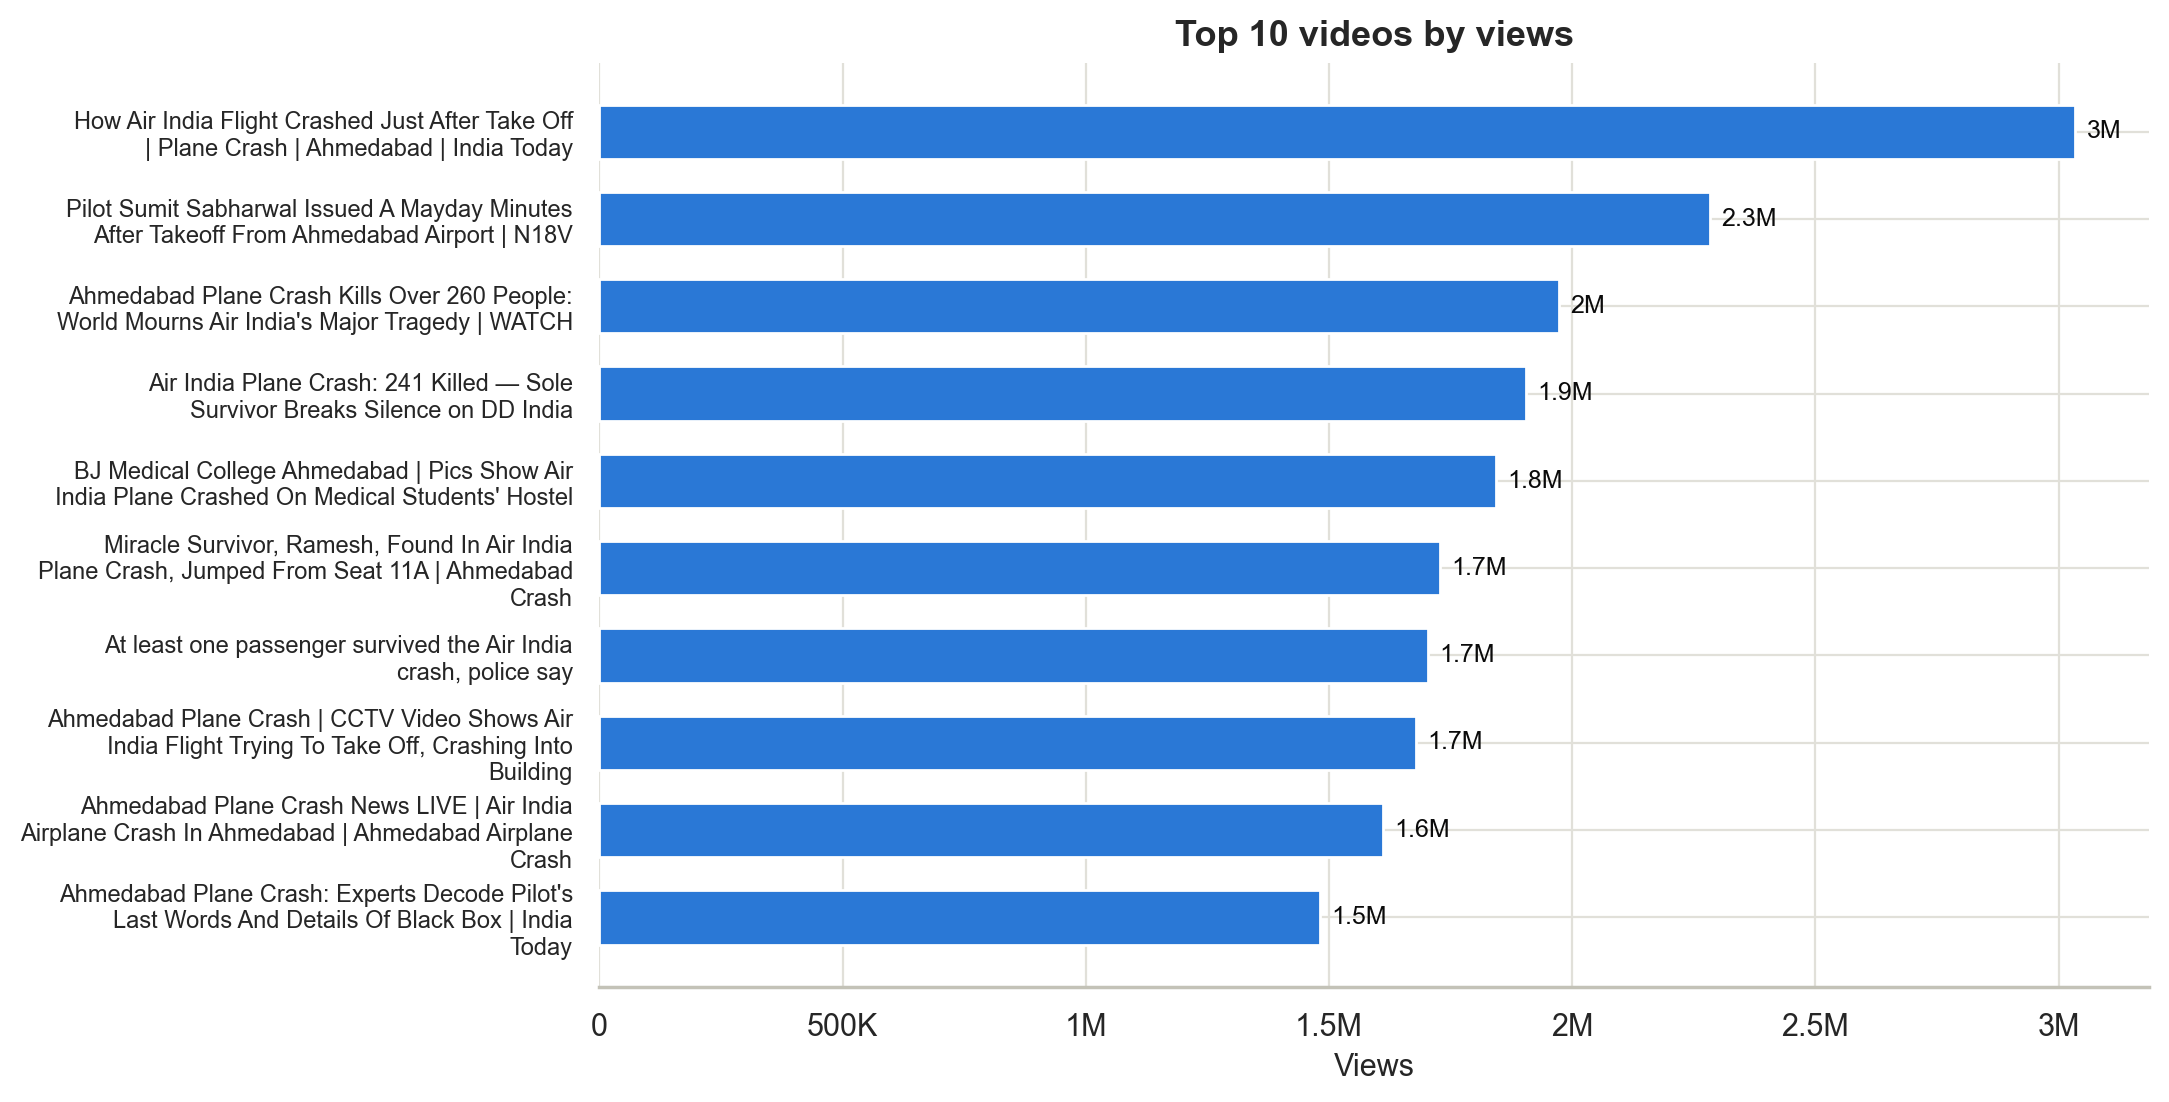

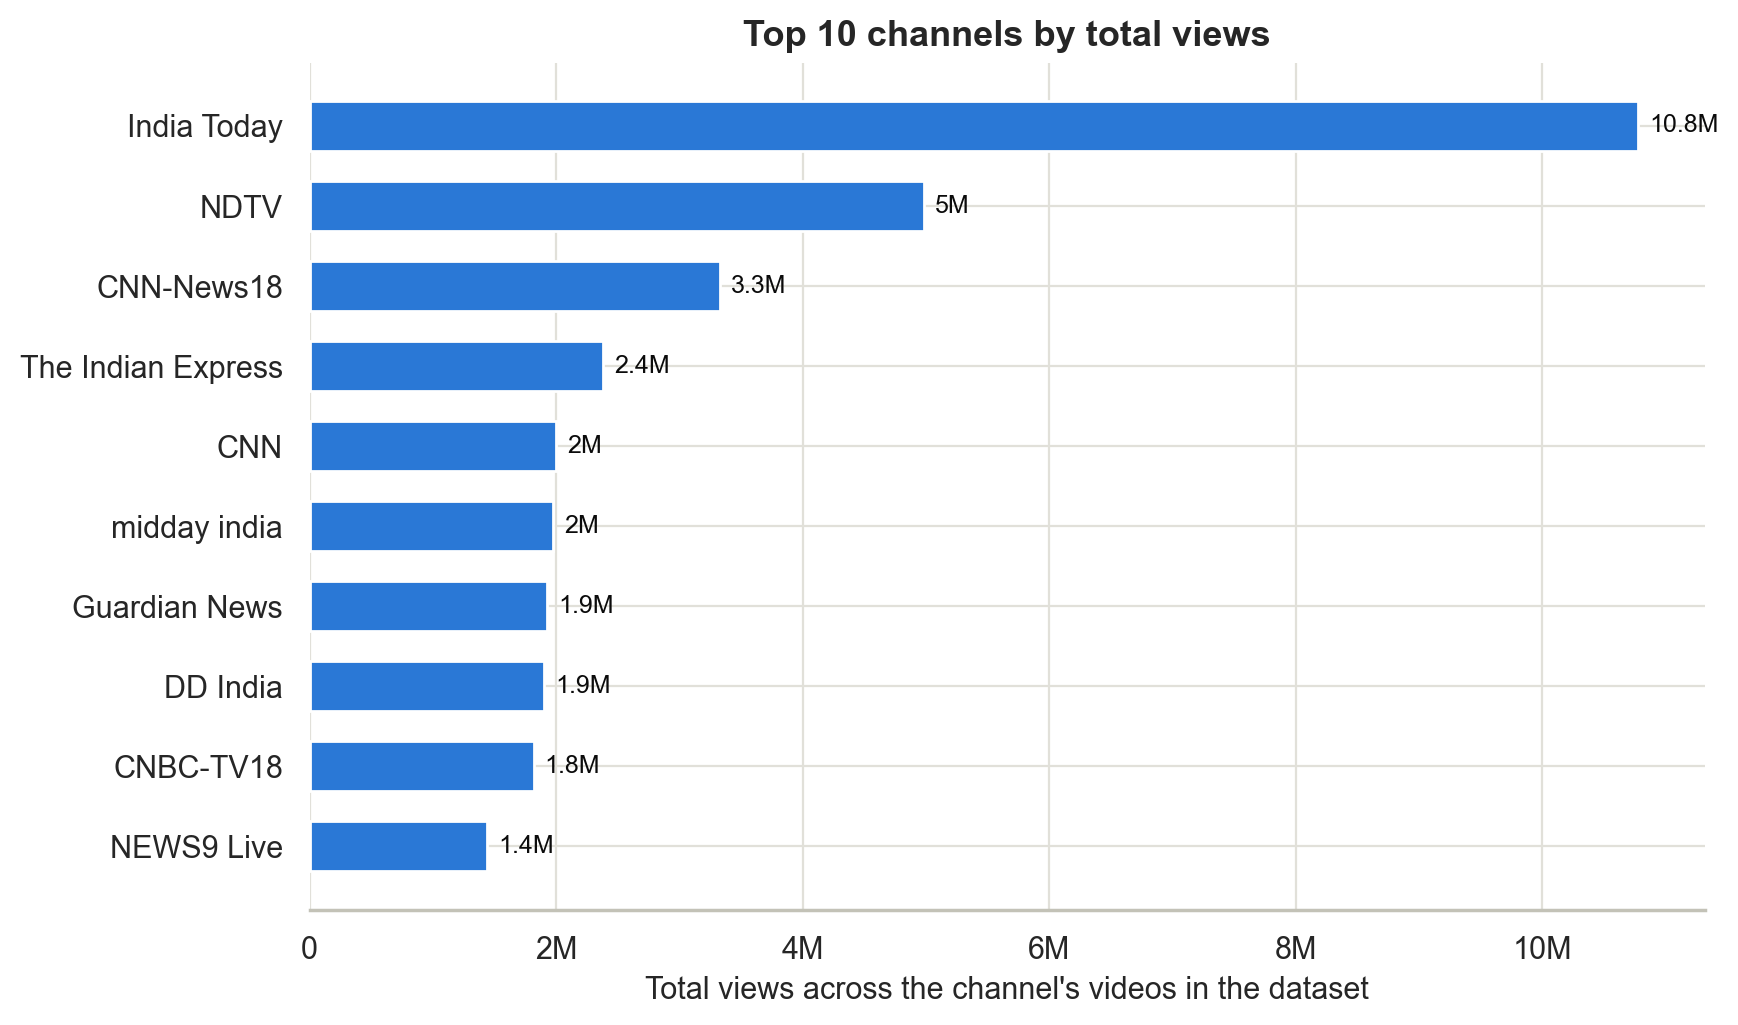

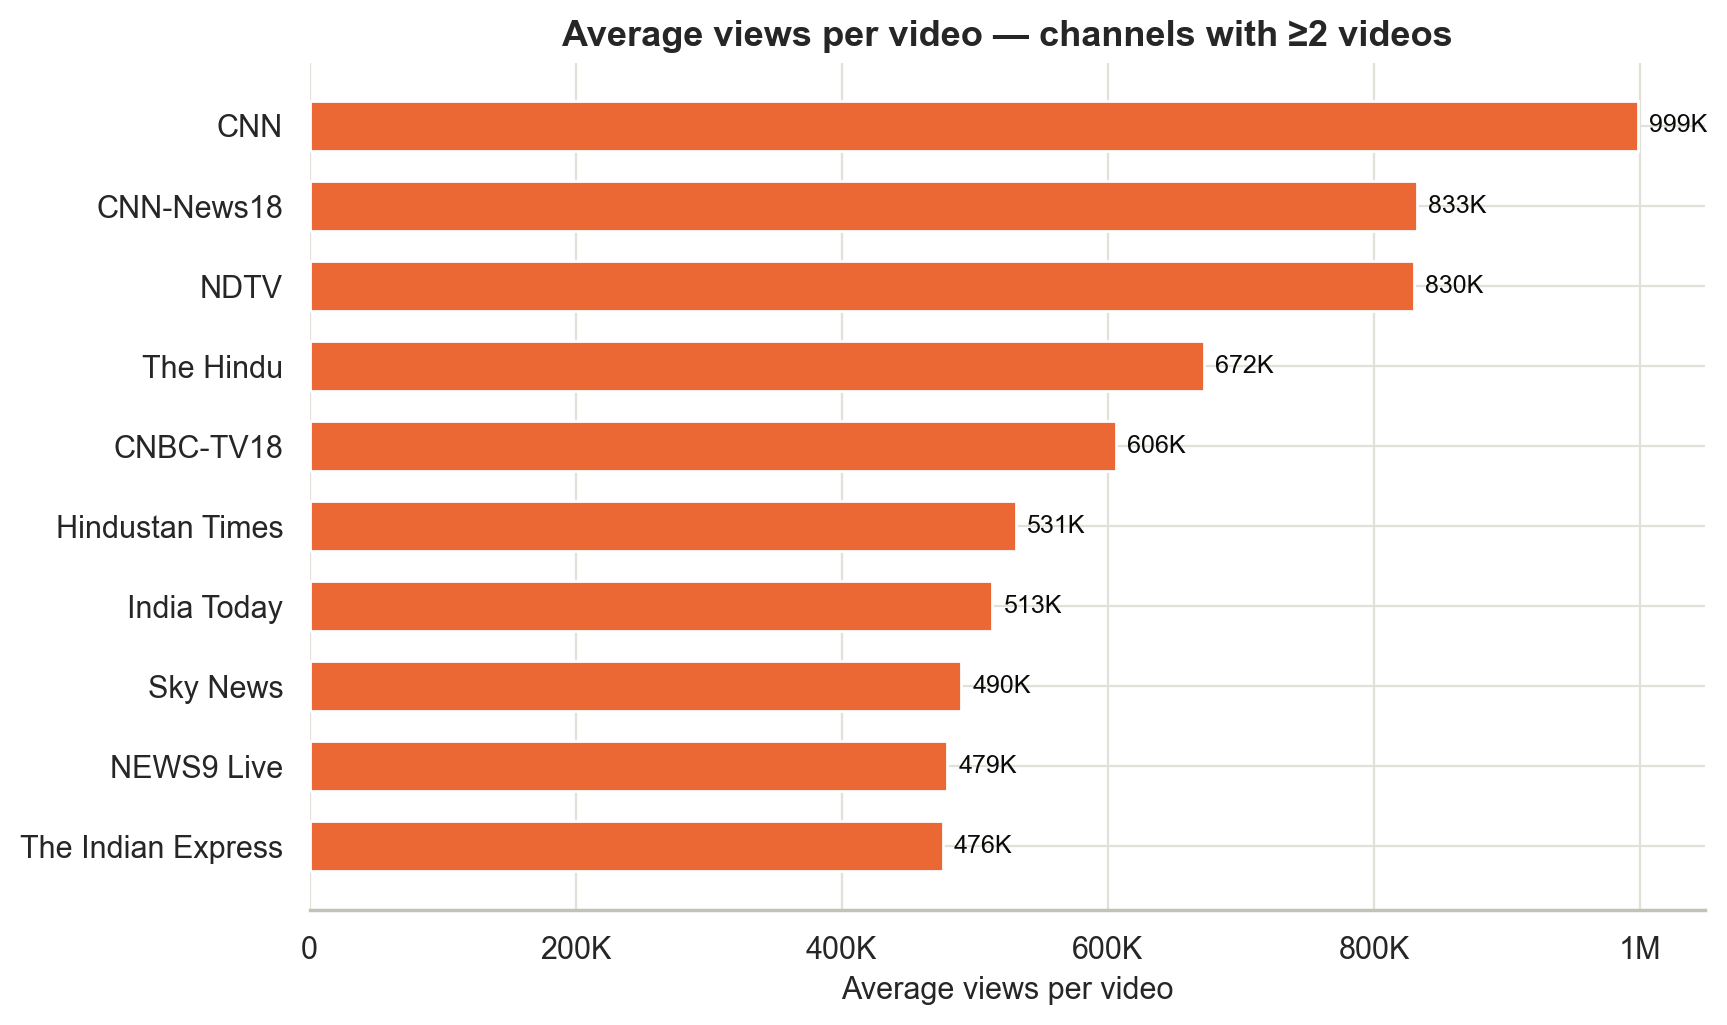

In [8]:
from IPython.display import Image, display
viz.top_videos_by_views(videos, CHARTS)
display(Image(CHARTS / "01_top10_videos_by_views.png", width=850))
viz.top_channels_by_views(channel_perf, CHARTS)
display(Image(CHARTS / "02_top10_channels_by_total_views.png", width=800))
viz.channel_avg_views(channel_perf, CHARTS)
display(Image(CHARTS / "03_channel_avg_views.png", width=800))

### 4.3 Distributions & correlations

Views are heavily right-skewed (a few blockbuster uploads), so log scales are used. With likes/comments unavailable, the correlation matrix covers the metrics that *do* exist: views, duration, title/description length, tag count.

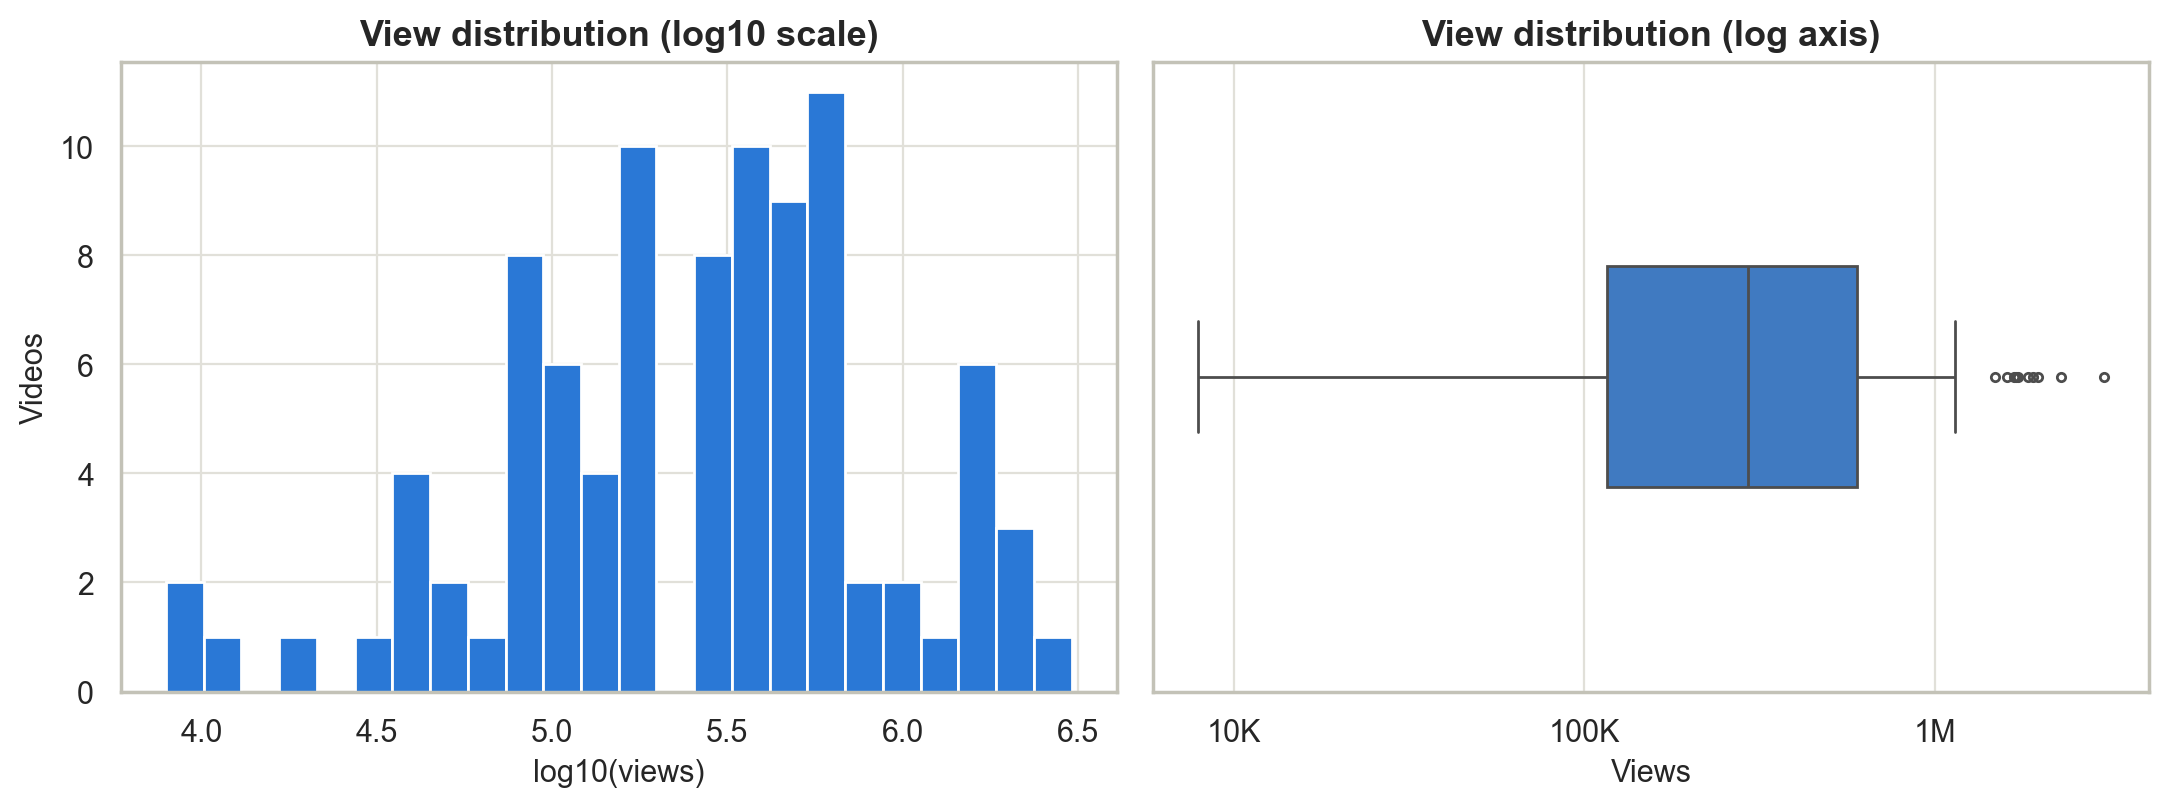

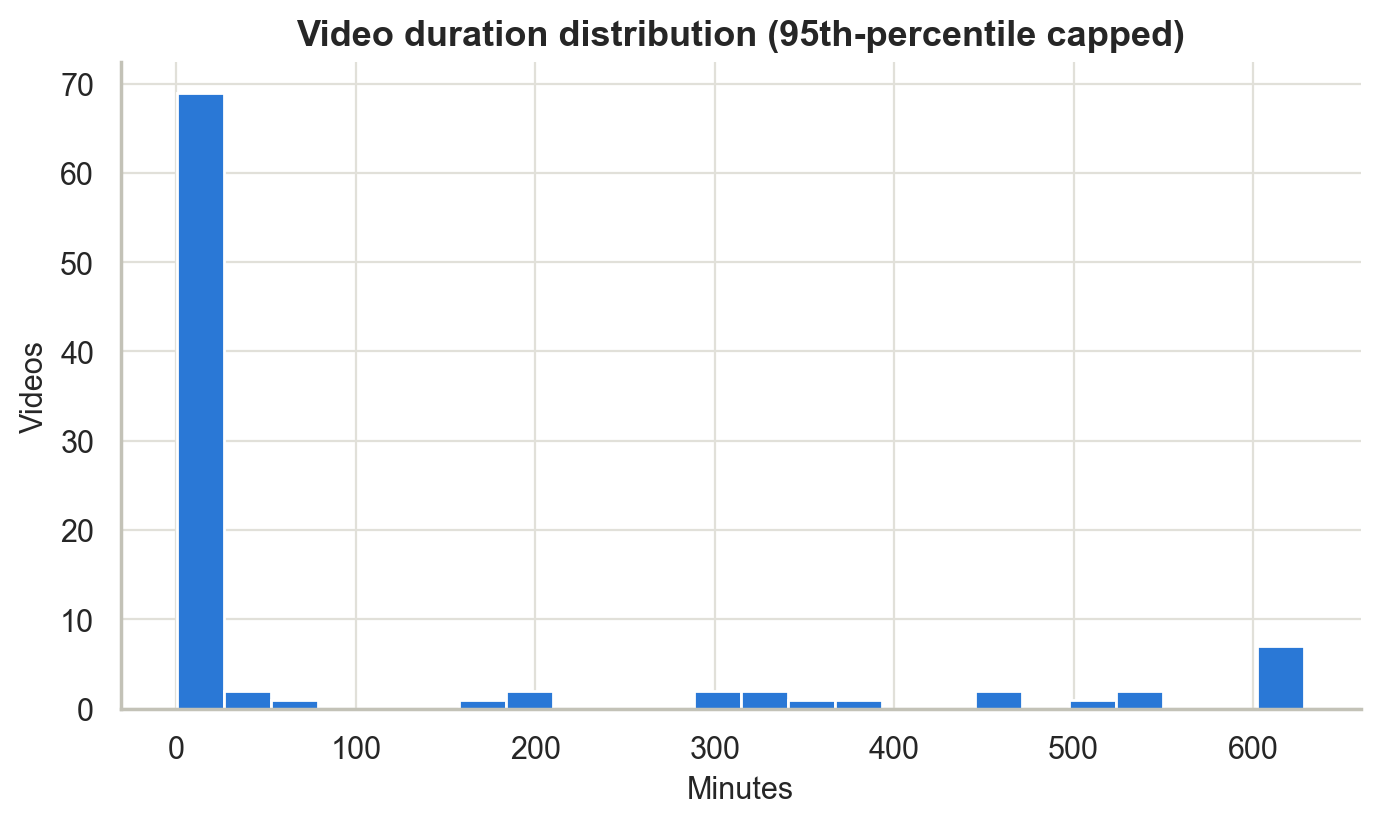

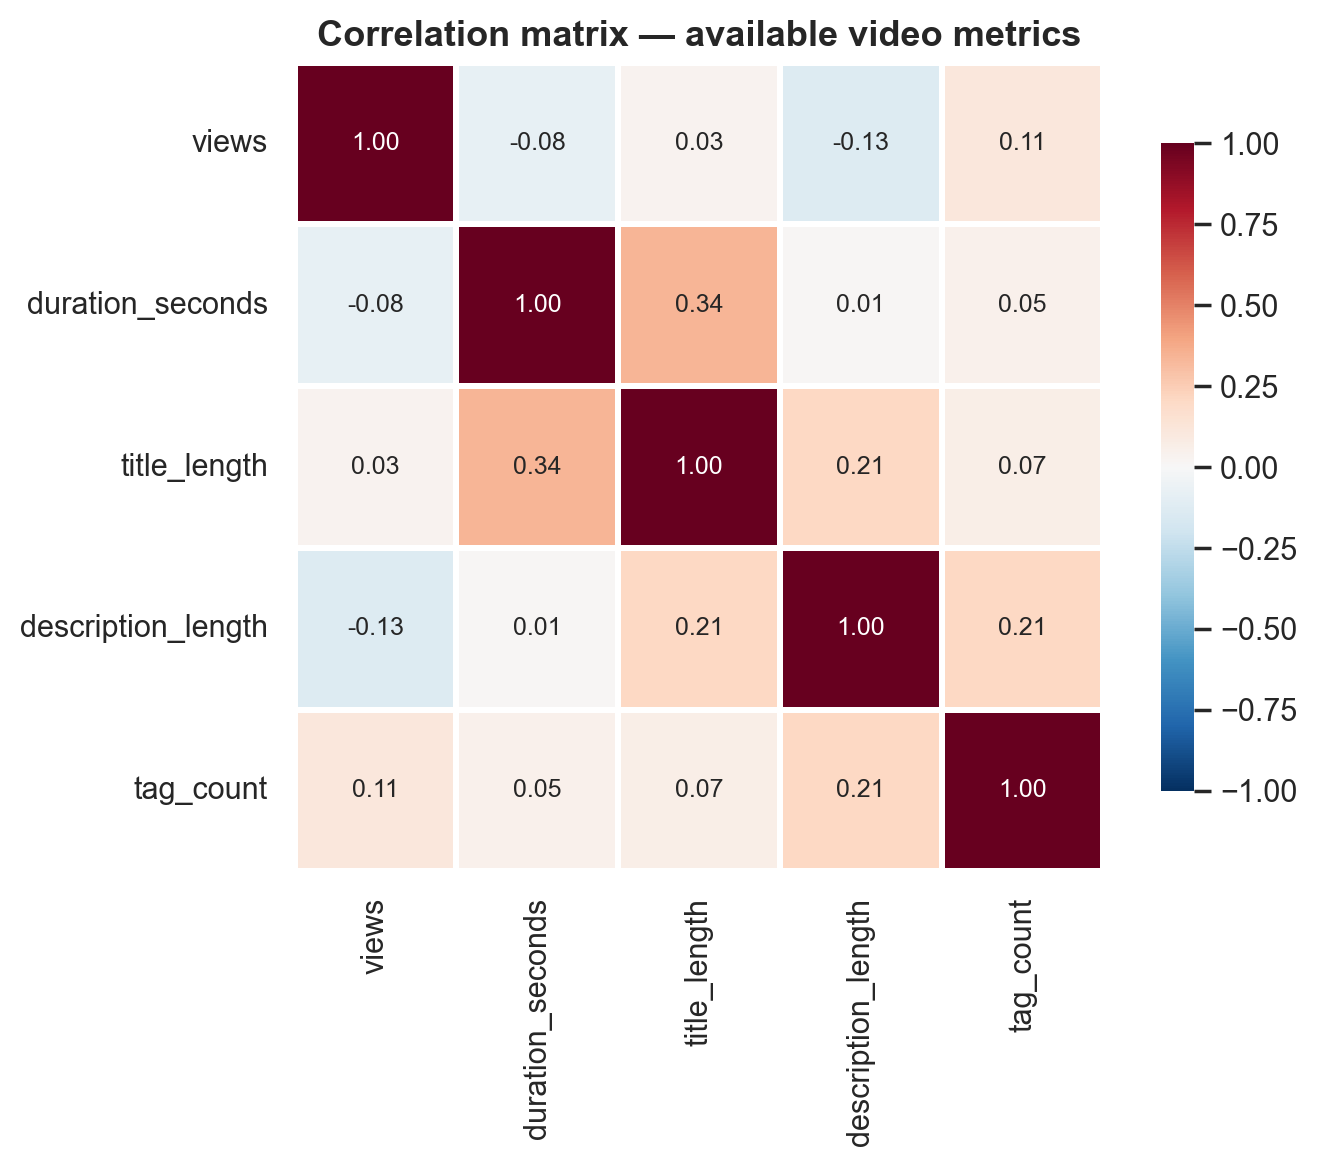

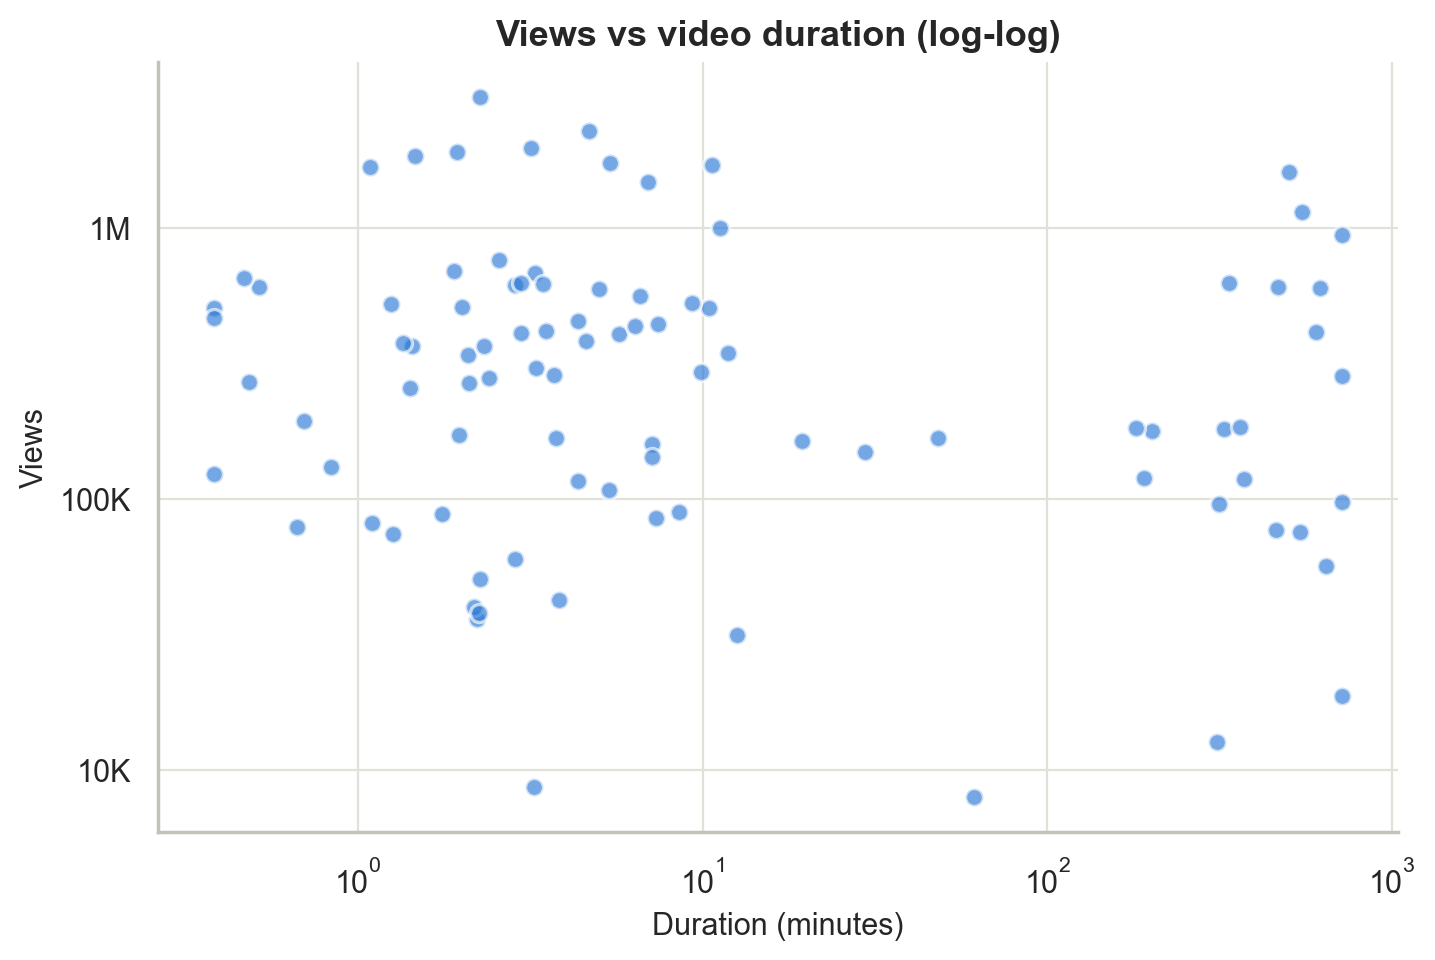

In [9]:
corr = da.correlation_matrix(videos)
viz.view_distribution(videos, CHARTS)
display(Image(CHARTS / "04_view_distribution.png", width=850))
viz.duration_distribution(videos, CHARTS)
display(Image(CHARTS / "05_video_duration_distribution.png", width=700))
viz.correlation_heatmap(corr, CHARTS)
display(Image(CHARTS / "06_correlation_heatmap.png", width=600))
viz.views_vs_duration(videos, CHARTS)
display(Image(CHARTS / "07_views_vs_duration.png", width=700))

## 5. Sentiment analysis (Phase 4)

VADER `SentimentIntensityAnalyzer`, standard thresholds: compound ≥ 0.05 → positive, ≤ −0.05 → negative, else neutral.

**Read the results carefully:** automated sentiment does not capture sarcasm, Hindi/Hinglish, or culturally specific mourning language, and grief vocabulary ("lost", "tragic", 😢) scores negative inside condolence messages. Negative share = sombre language, **not** public verdicts about the crash's cause.

In [10]:
scored = sa.analyze_comments(comments)
summary = sa.sentiment_summary(scored)
summary

,sentiment,count,percent,mean_compound
0,positive,5215,29.2,0.526
1,neutral,4542,25.5,0.000
2,negative,8081,45.3,-0.566


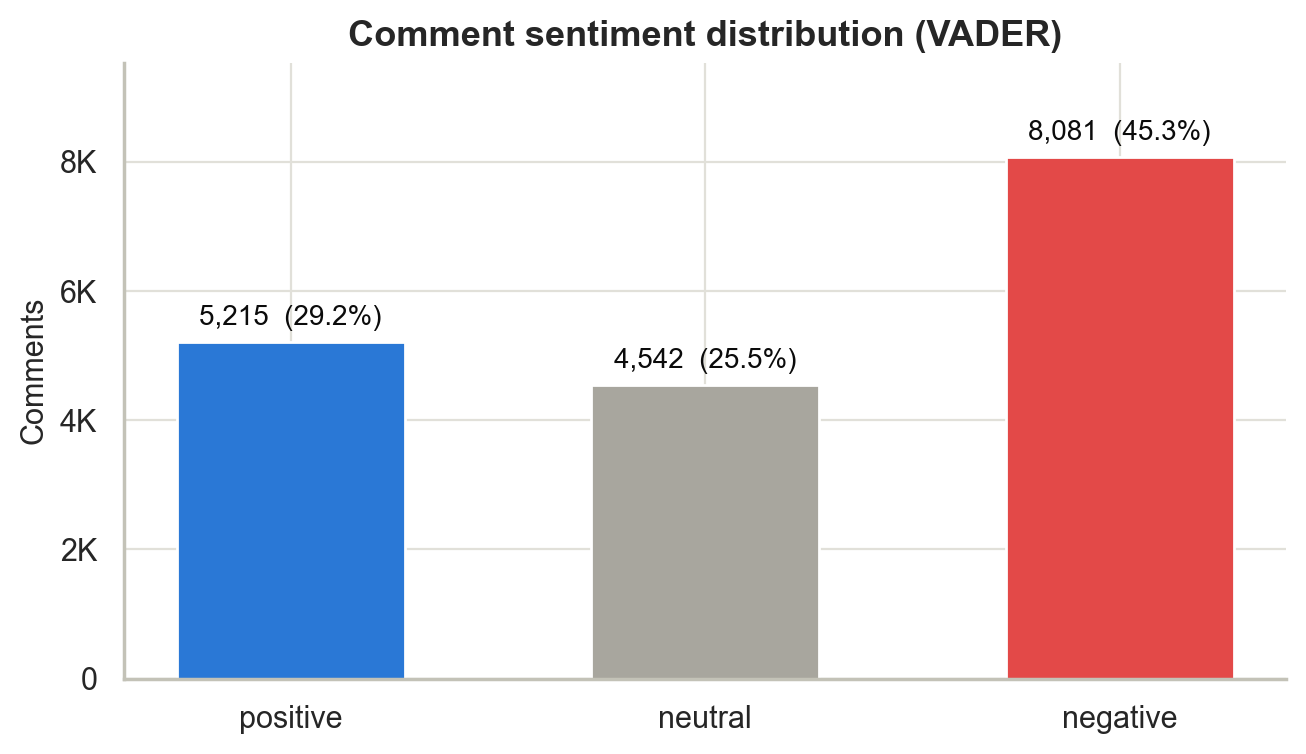

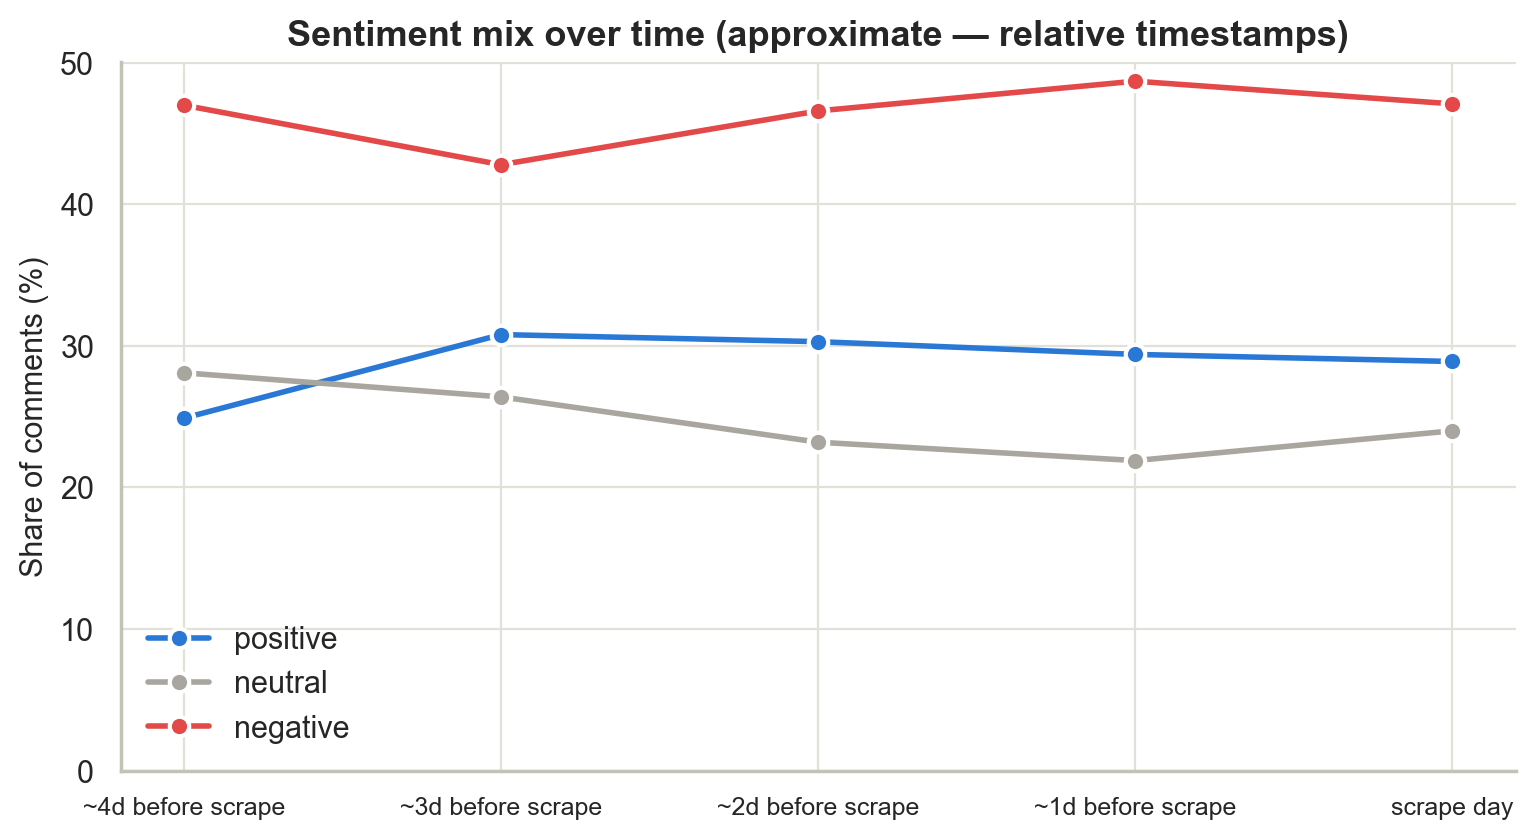

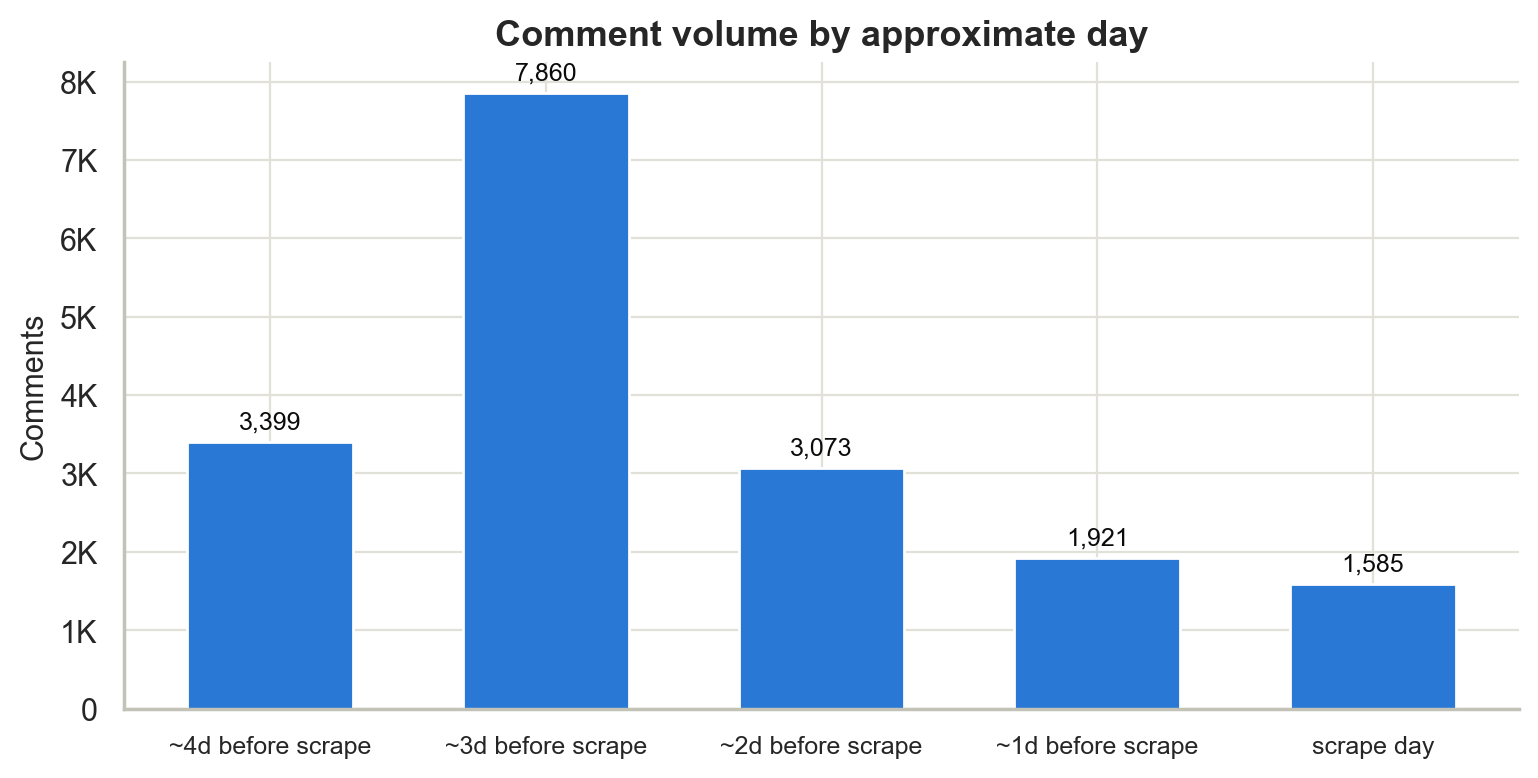

/Users/meghanak/Downloads/Claude/AirIndia/AirIndia_YouTube_Analytics/src/visualization.py:294: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="sentiment", y="comment_likes", order=order,


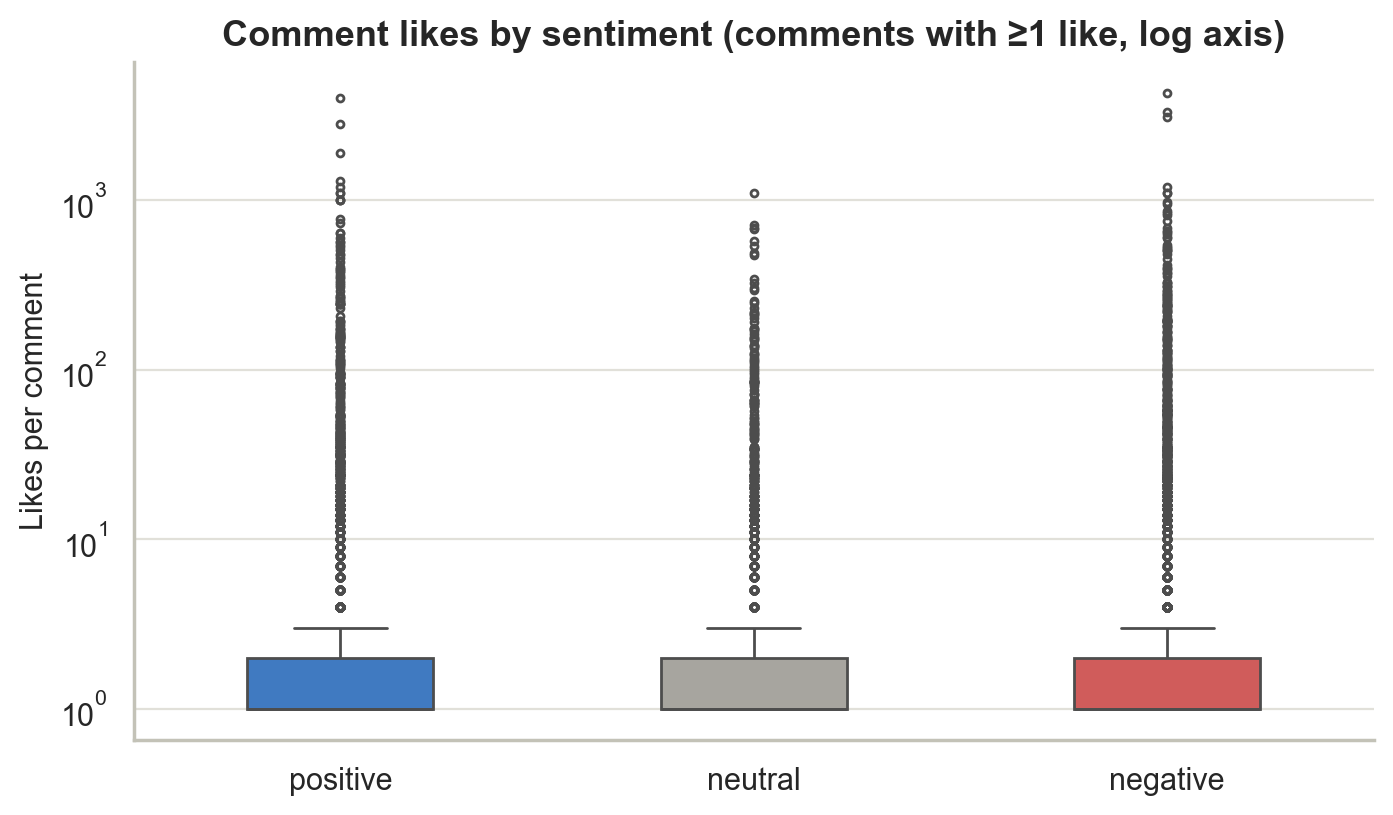

In [11]:
by_day = sa.sentiment_by_day(scored)
volume_by_day = da.comment_volume_by_day(comments)
viz.sentiment_distribution(summary, CHARTS)
display(Image(CHARTS / "08_sentiment_distribution.png", width=700))
viz.sentiment_trend(by_day, CHARTS)
display(Image(CHARTS / "09_sentiment_trend_over_time.png", width=800))
viz.comment_volume(volume_by_day, CHARTS)
display(Image(CHARTS / "10_comment_volume_by_day.png", width=800))
viz.comment_likes_by_sentiment(scored, CHARTS)
display(Image(CHARTS / "13_comment_likes_by_sentiment.png", width=700))

In [12]:
liked = sa.most_liked_by_sentiment(scored, n=3)
liked

,sentiment,comment_text,comment_likes,vader_compound
0,positive,He lost his bro and survived from massive explode. Leave him aloneeeee for c...,4000,0.3400
1,positive,Pilots are a rare breed of human beings . You did your best .,2800,0.6369
2,positive,Heard his brother was on the flight too but a different row. Truly devastati...,1900,0.4301
3,neutral,If you can survive this in one piece then you can survive anything.,1100,0.0000
4,neutral,Hospital should kick out these so called TRP journalists until his recovery,715,0.0000
5,neutral,"Not only did he survive, he walked out.",689,0.0000
6,negative,"He survived the accident, but now he has to survive the real danger — news c...",4300,-0.6996
7,negative,leave him alone... let him take his time to recover mentally..,3300,-0.2960
8,negative,"How this man walked away on his 2 legs from this horrific crash, is nothing ...",3100,-0.6643


## 6. Text & keyword analysis (Phase 5)

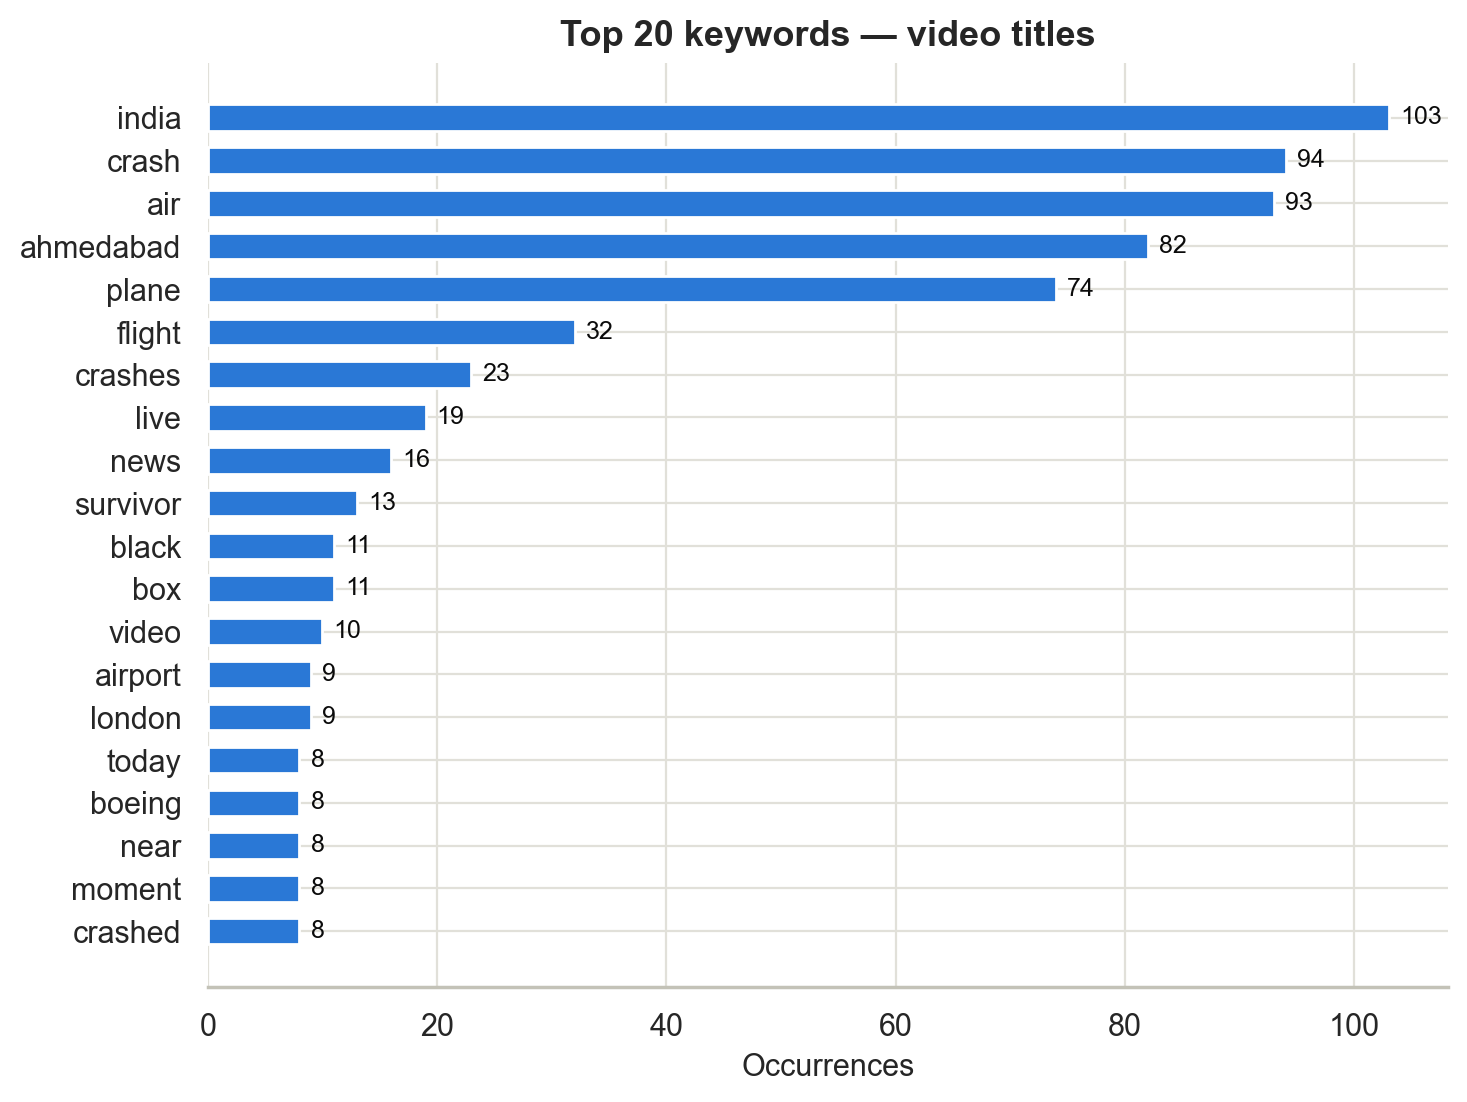

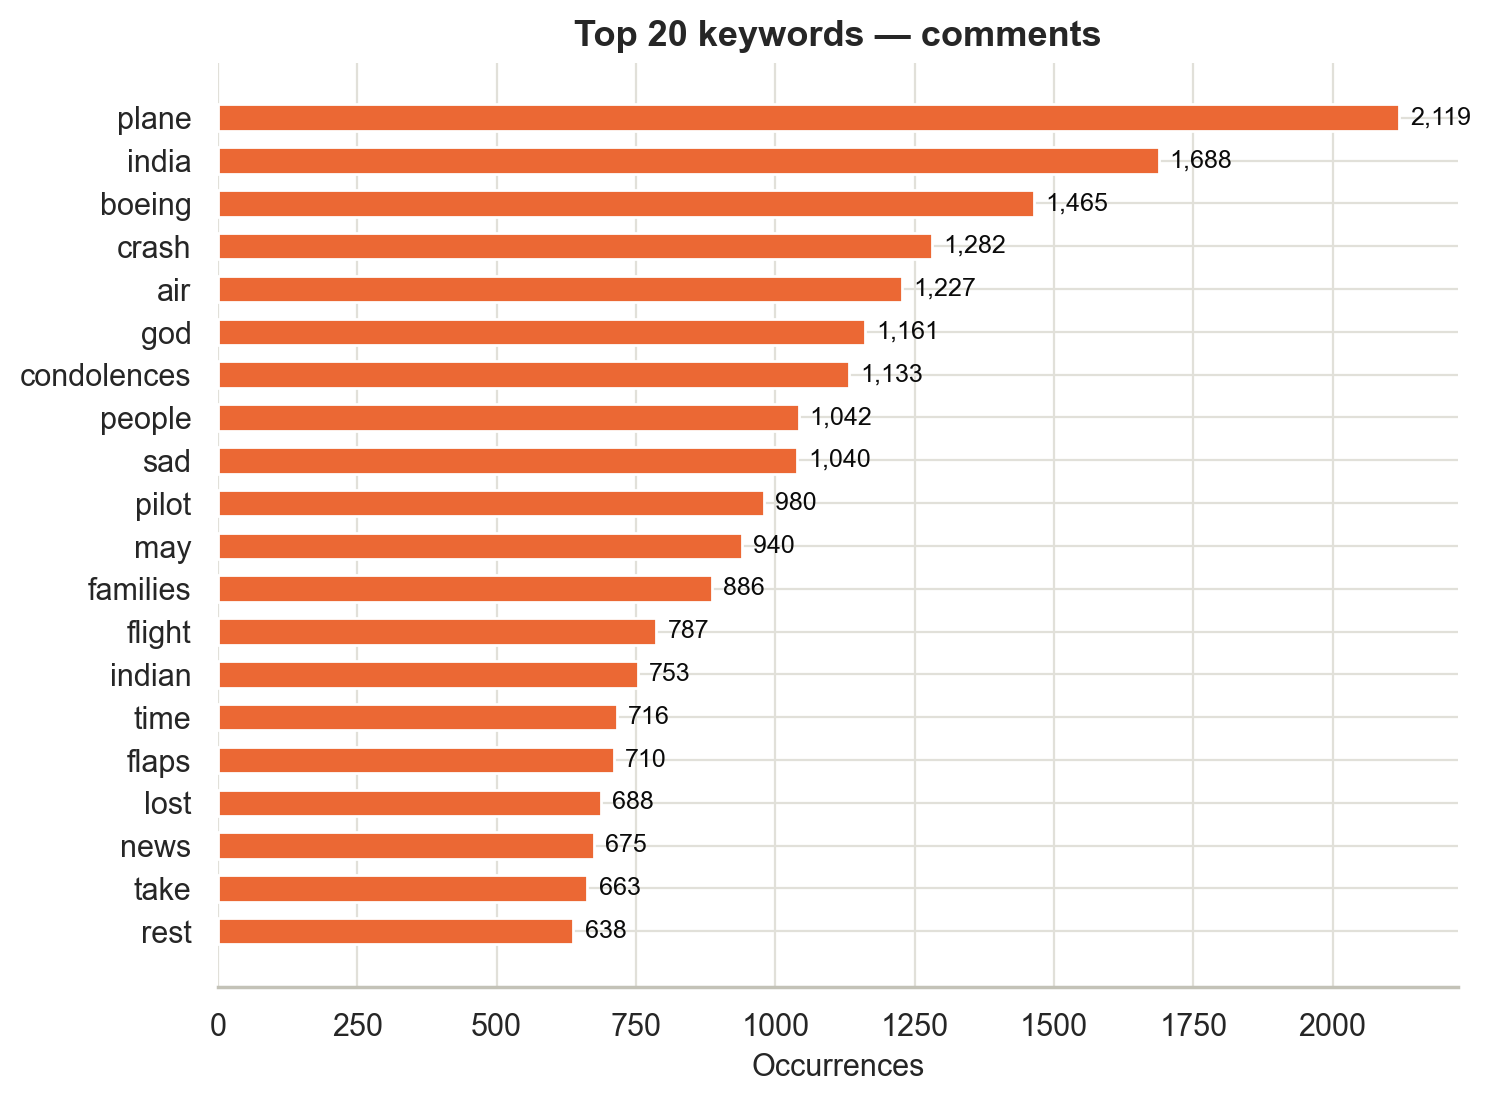

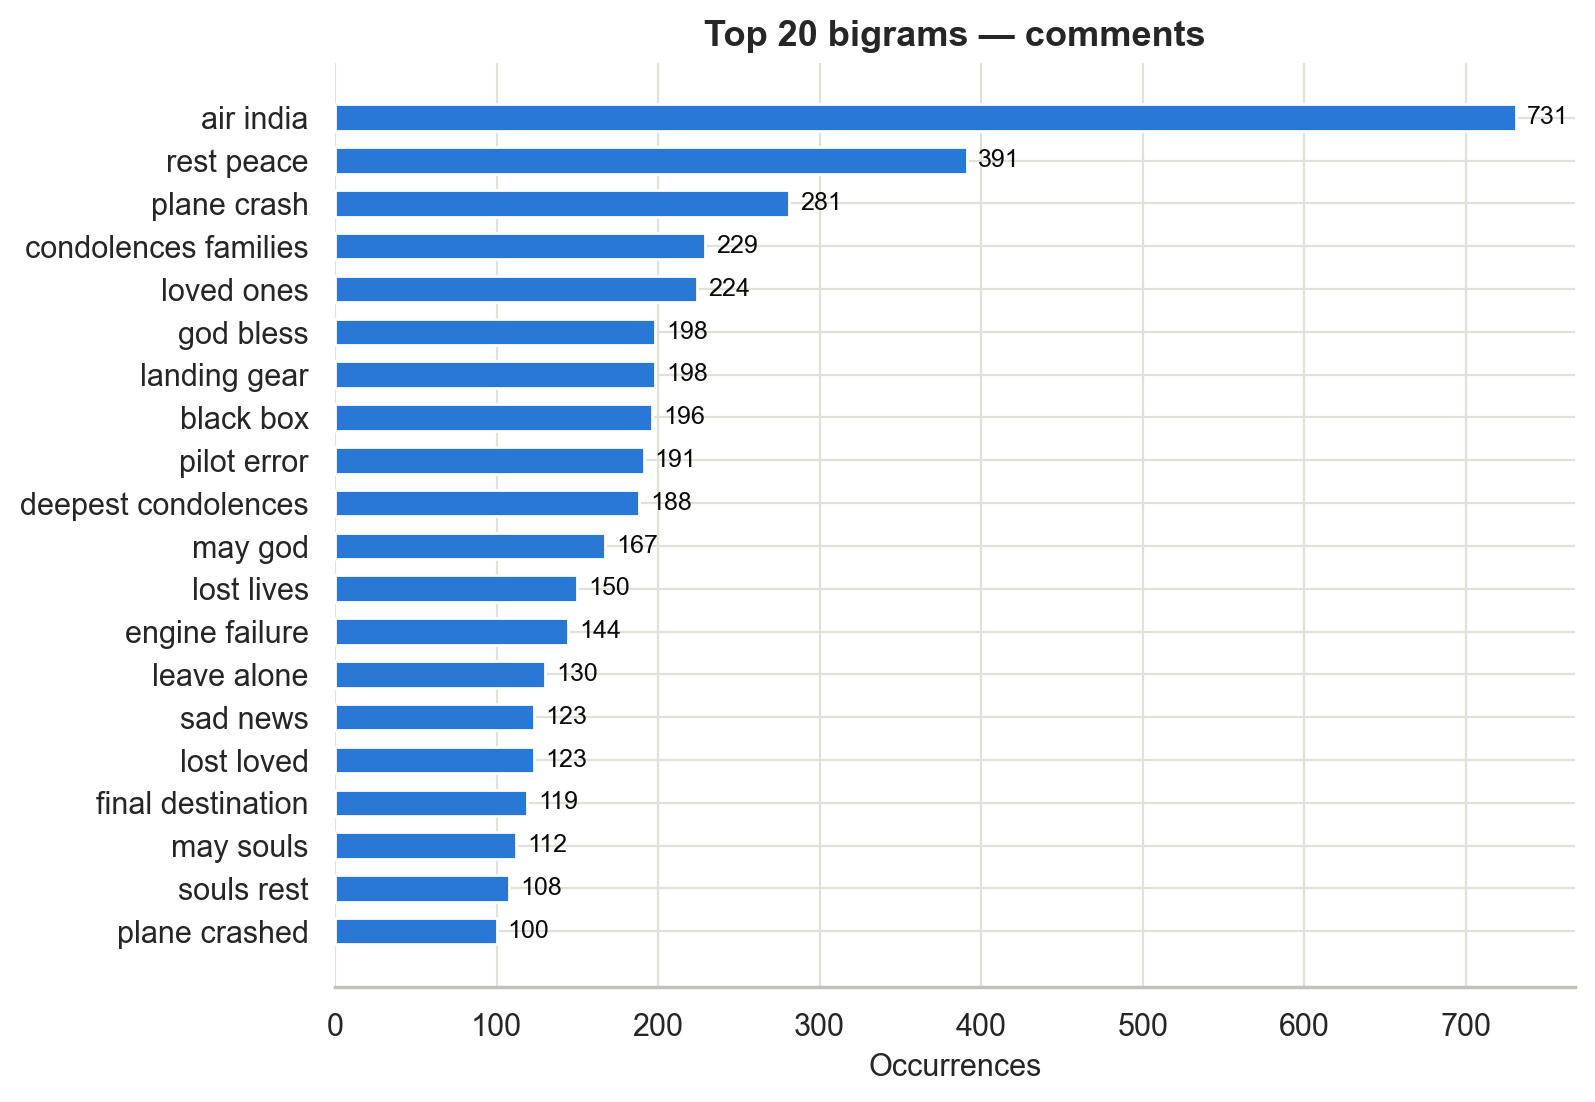

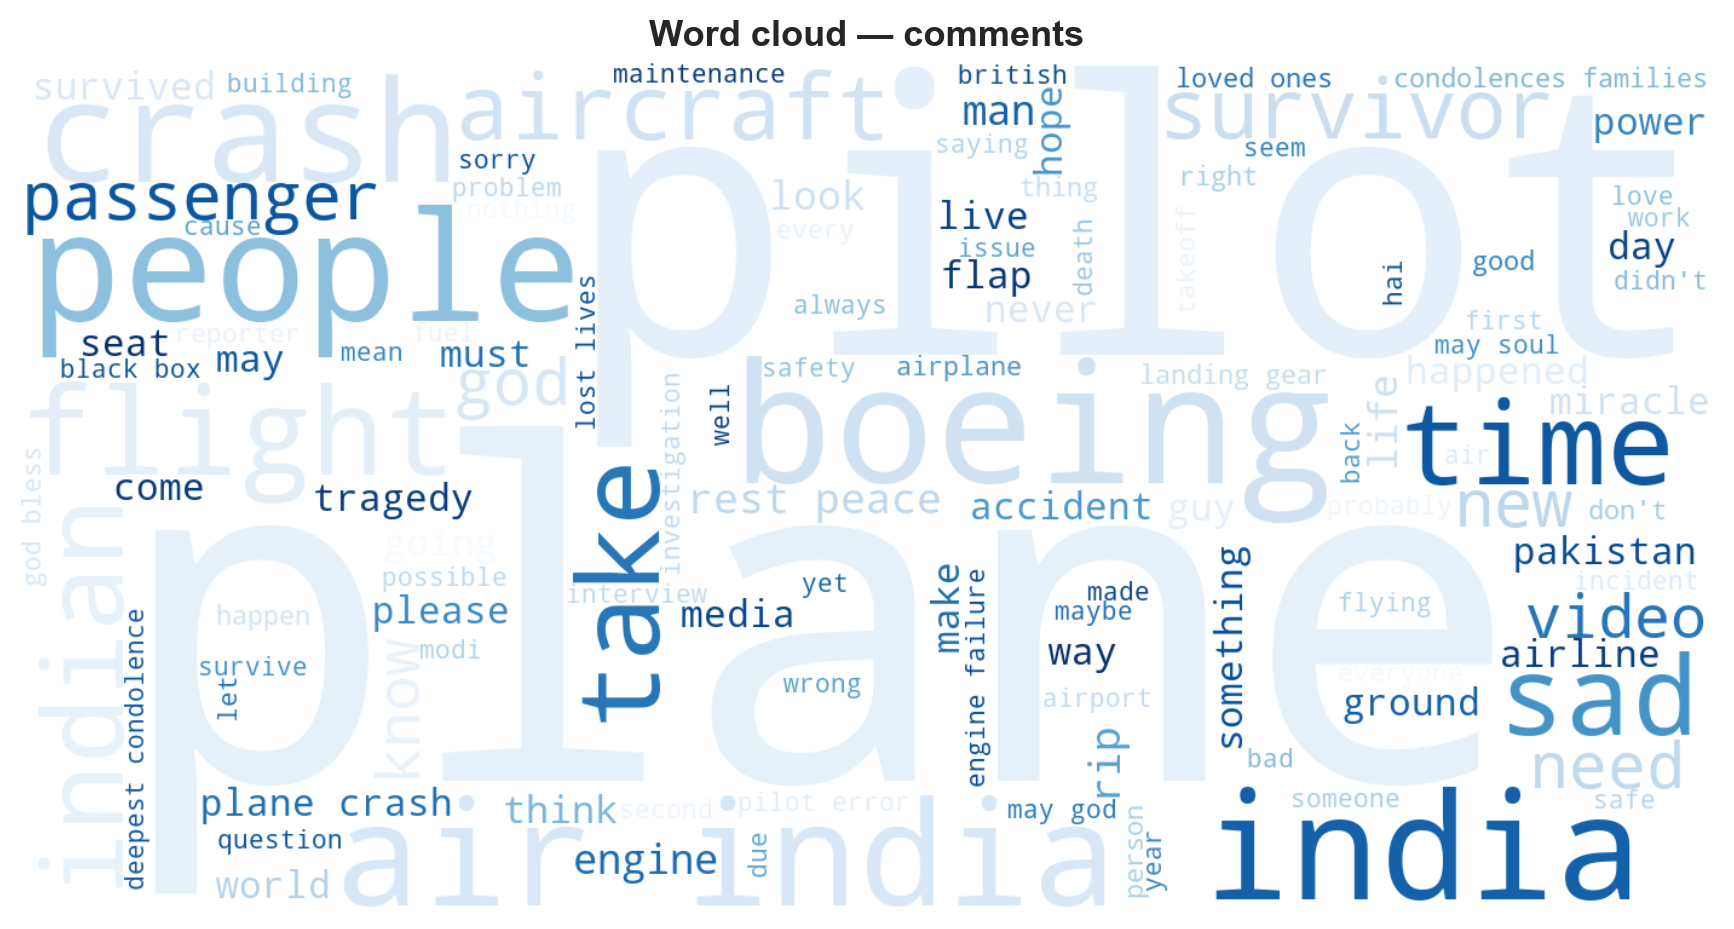

In [13]:
title_kw = da.top_terms(videos["title"], n=20)
comment_kw = da.top_terms(scored["comment_text"], n=20)
bigrams = da.top_terms(scored["comment_text"], n=20, ngram=2)

viz.keyword_bars(title_kw, CHARTS, "video titles", "11_top_keywords_titles.png")
display(Image(CHARTS / "11_top_keywords_titles.png", width=700))
viz.keyword_bars(comment_kw, CHARTS, "comments",
                 "12_top_keywords_comments.png", color=viz.ACCENT_2)
display(Image(CHARTS / "12_top_keywords_comments.png", width=700))
viz.keyword_bars(bigrams, CHARTS, "comments", "15_top_bigrams_comments.png")
display(Image(CHARTS / "15_top_bigrams_comments.png", width=700))
viz.wordcloud_chart(scored["comment_text"], CHARTS, "comments",
                    "14_wordcloud_comments.png")
display(Image(CHARTS / "14_wordcloud_comments.png", width=850))

## 7. SQL spot-checks (Phase 7)

The pipeline loads `videos`, `comments`, and `sentiment_results` into `air_india_youtube.db`. Full query set: [`sql/business_analysis.sql`](../sql/business_analysis.sql). Two examples:

In [14]:
import sqlite3
conn = sqlite3.connect(PROJECT_ROOT / "air_india_youtube.db")
print(pd.read_sql('''
    SELECT sentiment, COUNT(*) AS comments,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct,
           ROUND(AVG(vader_compound), 3) AS avg_compound,
           ROUND(AVG(comment_likes), 2) AS avg_likes_per_comment
    FROM sentiment_results GROUP BY sentiment ORDER BY comments DESC
''', conn).to_string(index=False))
print(pd.read_sql('''
    SELECT channel_name, COUNT(*) AS videos,
           CAST(SUM(views) AS INTEGER) AS total_views,
           RANK() OVER (ORDER BY SUM(views) DESC) AS rnk
    FROM videos GROUP BY channel_name ORDER BY total_views DESC LIMIT 5
''', conn).to_string(index=False))
conn.close()

sentiment  comments  pct  avg_compound  avg_likes_per_comment
 negative      8081 45.3        -0.566                   8.96
 positive      5215 29.2         0.526                  10.99
  neutral      4542 25.5         0.000                   5.44
      channel_name  videos  total_views  rnk
       India Today      21     10778558    1
              NDTV       6      4981761    2
        CNN-News18       4      3330577    3
The Indian Express       5      2378918    4
               CNN       2      1997052    5


## 8. Skipped analyses & limitations

Automatically recorded whenever a required column was absent:

In [15]:
pd.DataFrame(da.skipped, columns=["analysis", "reason"]).drop_duplicates()

,analysis,reason
0,engagement_rate,"missing column(s): likes, comment_count"
1,like_to_view_rate,missing column(s): likes
2,comment_to_view_rate,missing column(s): comment_count
3,video time features,missing column(s): published_date
4,dataset date range,no published_date column


## 9. Conclusions

See [`outputs/insights/business_insights.md`](../outputs/insights/business_insights.md) for the full data-supported findings. Headlines:

1. **Coverage was broad, attention concentrated** — 93 videos across 42 channels, but the top 5 channels hold ~52% of the 45M total views; India Today alone published 21 videos (22.6% of coverage) for 10.8M views.
2. **Human-story framings led** — "survivor" appears in 19 of 93 titles, including 4 of the top 10 videos by views.
3. **Comment tone is sombre, not hostile** — 45.3% negative / 29.2% positive / 25.5% neutral, mean compound −0.10; top bigrams are *rest peace*, *condolences families*, *loved ones* — condolence language that VADER scores negative.
4. **Positive (hope/gratitude) comments resonate most per comment** — 11.0 average likes vs 9.0 (negative) and 5.4 (neutral).
5. **Tone was stable across the five days scraped** — negative share stayed within 42.8–48.7% with no escalation.

**Limitations:** single-video comment sample (Firstpost); no video likes/comment-counts/publish dates; relative timestamps only (±1 day); VADER under-reads Hinglish and mourning idiom. None of this analysis speaks to the cause of the crash.